In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [102]:
file = "/cluster/projects/nn9481k/Climate_downscaling/NORCPM2_bias/bias_NorCPM_ERA5_64M_TREFHT_20n_cal.nc"

ds = xr.open_dataset(file)

In [ ]:
k = 0.5

fit = ds["TREFHT"].polyfit(dim="time", deg=1)
trend = xr.polyval(ds["time"], fit.polyfit_coefficients)

# The bias is corrected by removing the trend and adding back the value at month 8 to maintain the temperature around summer.
ds["TREFHT"] = k * (ds["TREFHT"] - trend) + ds["TREFHT"].isel(time=8) - k * (ds["TREFHT"].isel(time=8) - trend.isel(time=8))
#ds["TREFHT"] = k * (ds["TREFHT"] - trend) + trend.mean(dim="time")

<xarray.DataArray 'TREFHT' ()> Size: 8B
array(-2.02999388)
Coordinates:
    lon      float64 8B 18.75
    lat      float64 8B 73.98
Attributes:
    units:          K
    CDI_grid_type:  gaussian
    cell_methods:   time: mean
    standard_name:  time
    axis:           T
    long_name:      Reference height temperature


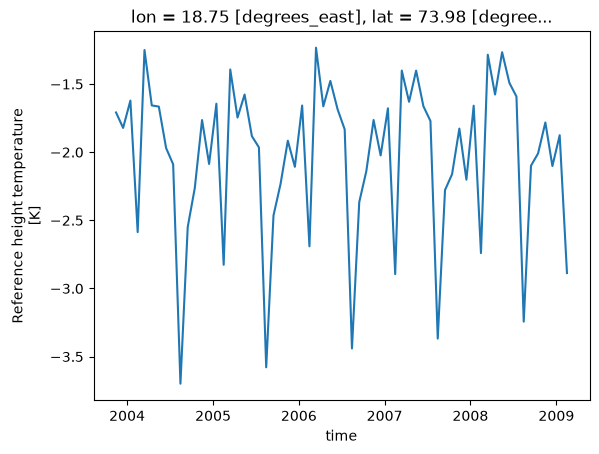

In [ ]:
# Checking a few points to see if the bias correction worked as expected
temp = ds["TREFHT"].sel(lat=74.09, lon=19.1, method="nearest")
temp.plot()
print(temp.mean())

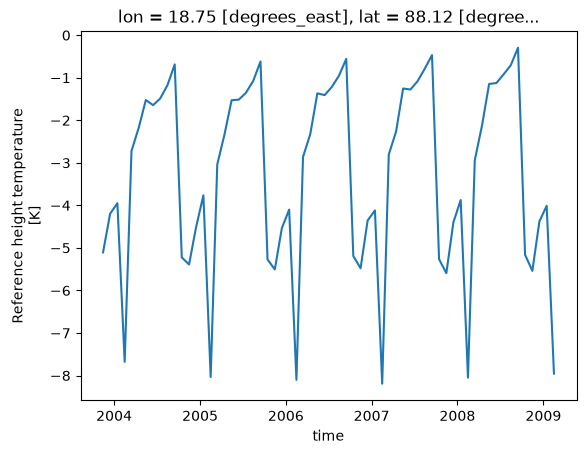

In [105]:
temp = ds["TREFHT"].sel(lat=88, lon=19.1, method="nearest")
temp.plot()

In [106]:
ds

<xarray.Dataset> Size: 11MB
Dimensions:  (time: 64, lat: 75, lon: 288)
Coordinates:
  * time     (time) datetime64[ns] 512B 2003-11-15 2003-12-15 ... 2009-02-15
  * lat      (lat) float64 600B 20.26 21.2 22.15 23.09 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    TREFHT   (time, lat, lon) float64 11MB -2.065 -1.968 ... -7.137 -7.137
Attributes: (12/13)
    CDI:               Climate Data Interface version 2.6.0 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    case:              noresm2-mm-seaclim_hindcast_19931101_mem001
    logname:           ingo
    host:              
    ...                ...
    topography_file:   /cluster/shared/noresm/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  month_1
    history:           Wed May 13 16:45:27 2026: cdo -O setreftime,1950-01-01...
    NCO:               netCDF Operators version 5.3.4 (Homepage = http://nco....
    CDO:               Climate Data Operators version 2.6.0 (https://mpimet.m...

In [ ]:
# Uncomment the following line to save the corrected dataset to a new NetCDF file
#ds.to_netcdf("/cluster/projects/nn9481k/arnaud/atm_bias/bias_NorCPM_ERA5_64M_TREFHT_20n_cal.nc")